In this notebook, we define a contrastive model to predict $\texttt{VTE}$, using the fully imputed and pre‑processed dataset $\texttt{df\_ready}$ ($\texttt{synthetic\_clinical\_data}$ for reproductiblity). We will later compare it against the same model without the contrastive part (only with Neural network and Random forest). We also evaluate performance across multiple test sizes, allowing us to assess whether contrastive learning provides greater benefits—especially when less data is available.

The accuracy results from the predictions (ROC-AUC and PR-AUC) will be saved on $\texttt{results/6.synthetic\_contrastive}$. A summary table is provided at the end of the notebook, reporting the mean ROC‑AUC, PR‑AUC, and accuracy values. These averages are computed across multiple runs using different random states.

These results will later be compared with the performance of the same model after removing the variables identified as uninformative by the gating mechanism. This will allow us to assess whether the gating‑based feature selection genuinely improves predictive accuracy.

# Contrastive model

## Imports

In [1]:
import numpy as np
import pandas as pd
import os

import gc

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)

## Data loading

In [2]:
path_data = "dataframes\synthetic_clinical_data.csv"
df = pd.read_csv(path_data)

X = df.drop(columns=["VTE"]).values.astype(np.float32)
y = df["VTE"].values.astype(np.int64)

test_size = 0.9
random_state = 42

d_init = X.shape[1]
d_init

39

### Create the $\texttt{.csv}$ file

In [3]:
results_path = "results/6.synthetic_contrastive.csv"

# Check if file exists
if not os.path.exists(results_path):
    print("File not found. Creating new results file...")

    df_results = pd.DataFrame(columns=[
        "model",
        "random_state",
        "test_size",
        "n_epochs",
        "margin",
        "batch_size",
        "learning_rate",
        "weight_decay",
        "scheduler_step_size",
        "scheduler_gamma",
        "ROC-AUC",
        "PR-AUC",
        "Accuracy"
    ])

    df_results.to_csv(results_path, index=False)
else:
    print("Results file already exists.")
    df_results = pd.read_csv(results_path)

df_results.head()

Results file already exists.


,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
0,Contrastive,0,0.20,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.577024,0.306672,0.693095
1,Contrastive,5,0.20,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.543626,0.304391,0.693095
2,Contrastive,42,0.20,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.488178,0.299732,0.675192
3,Contrastive,0,0.33,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.519489,0.298621,0.675192
4,Contrastive,5,0.33,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.601720,0.356796,0.710997


## Kernel functions

### Dataset classes

In [4]:
from utils import PairDatasetBalanced

### Model + loss

In [5]:
from utils import DeepKernel, cosine_hinge_loss, hinge_loss

### Training / evaluation loops

In [6]:
from utils import train_one_epoch_contrastive, eval_one_epoch

### Fit

In [7]:
from utils import fit, plot_history, transform_dataset_contrastive

## Training setup

### Model Variables

In [8]:
model_name="Contrastive"

FOLDS=10

bsize = 32
d_out = 16

learning_rate = 5e-4
weight_decay = 1e-8

scheduler_step_size = 300
scheduler_gamma = 0.01

epochs = 100
margin = 0.3    

# scheduler = None    # disable for now

#### Device and empty cache

In [9]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using {device} device")

Using cpu device


#### Define the StratifiedShuffleSplit

In [10]:
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=random_state)

all_preds = []
all_y = []
all_probs = []

## Training the model


Fold 1


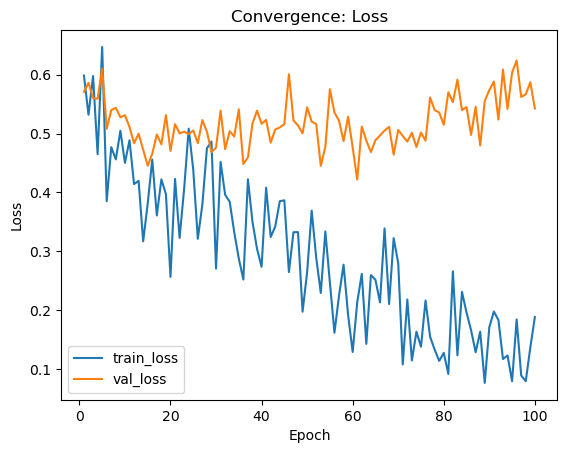

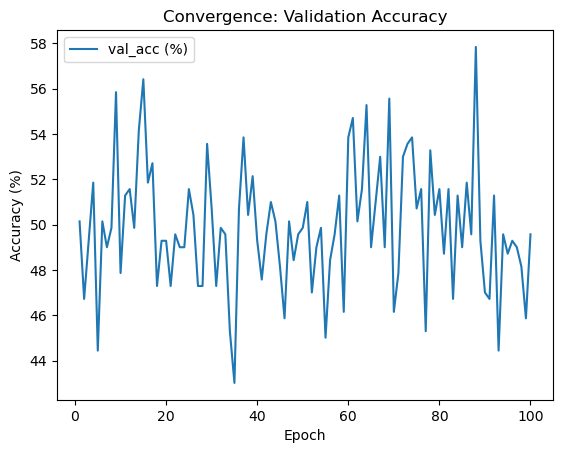


Fold 2


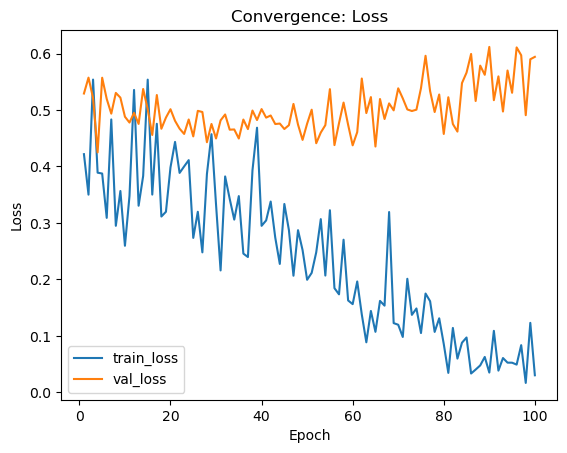

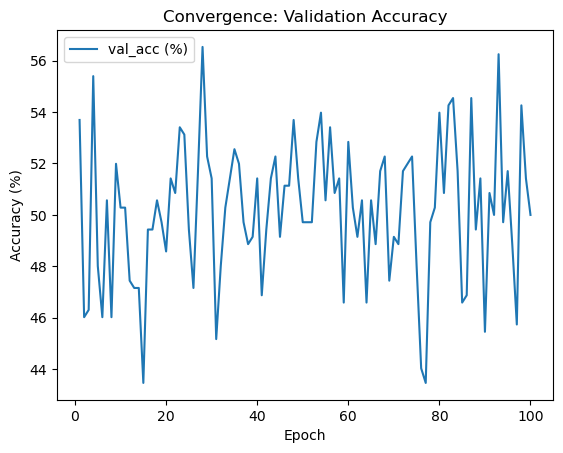


Fold 3


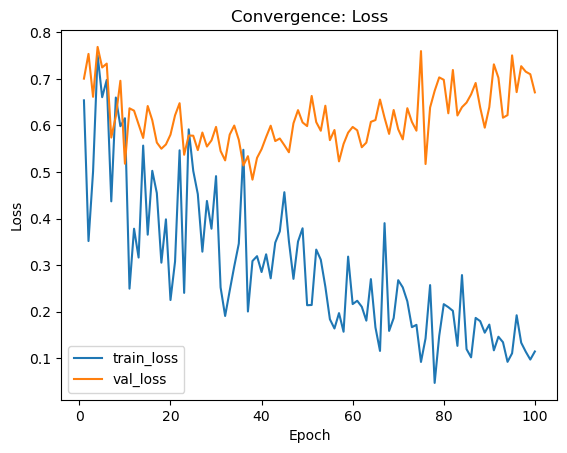

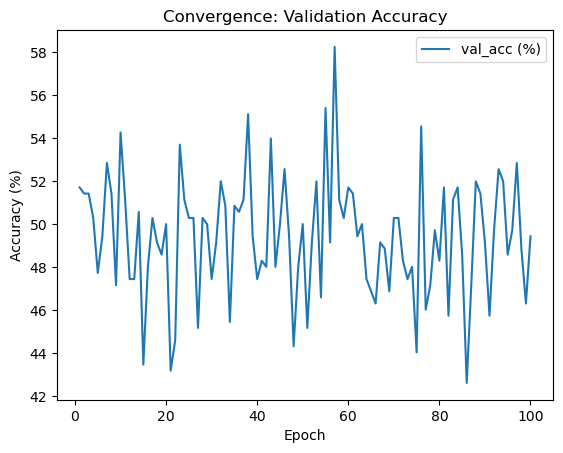


Fold 4


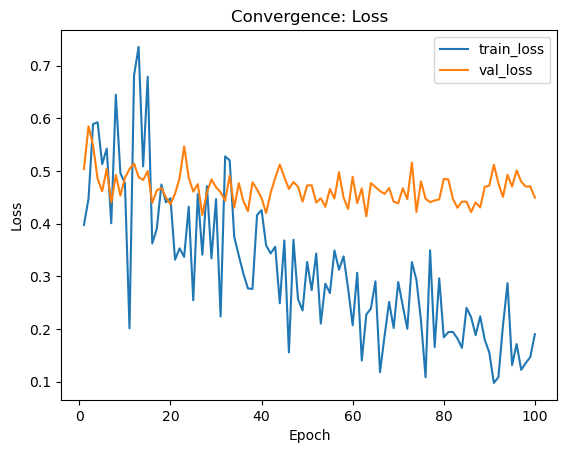

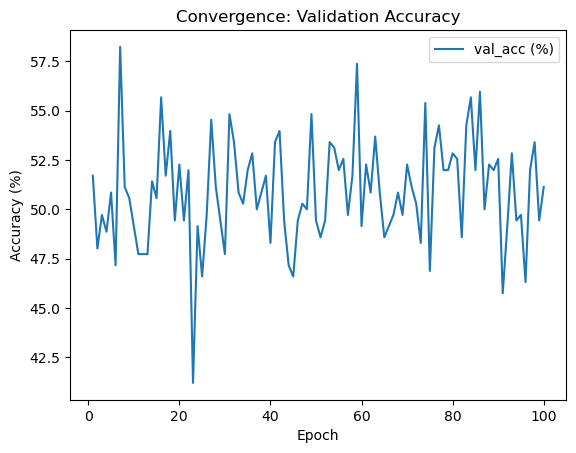


Fold 5


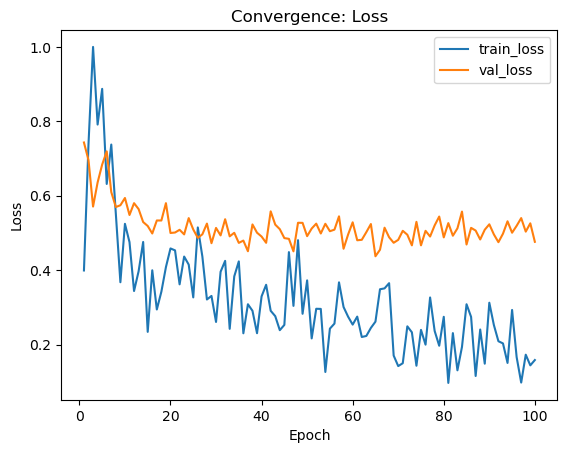

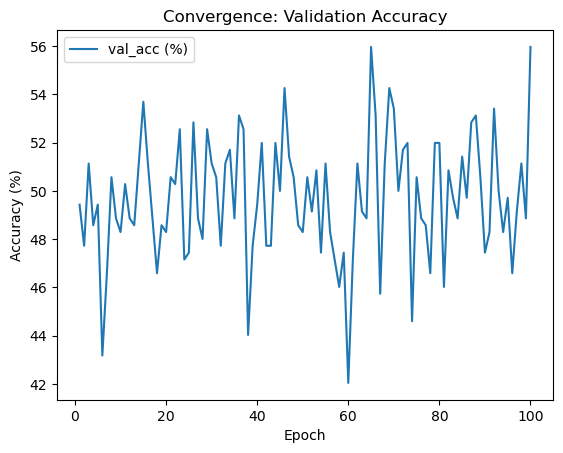


Fold 6


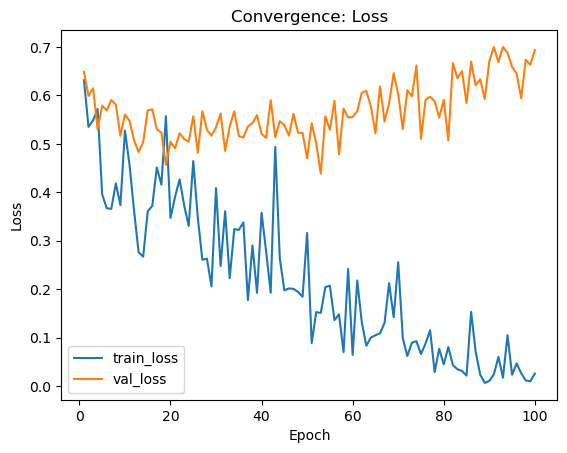

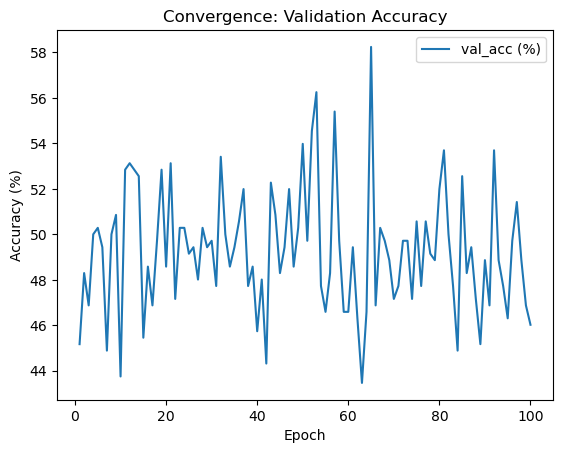


Fold 7


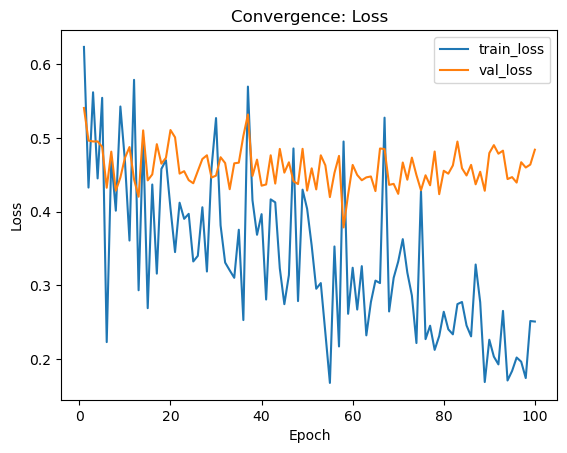

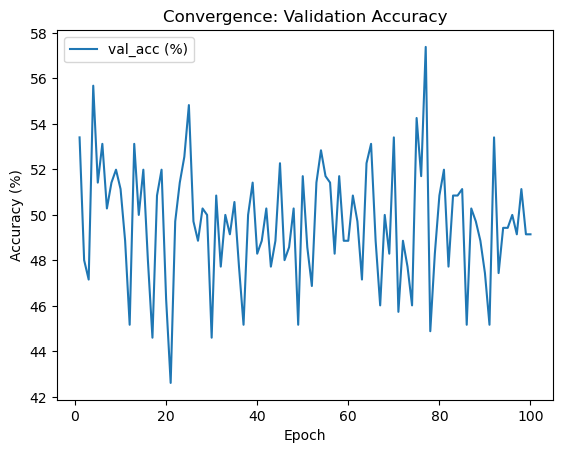


Fold 8


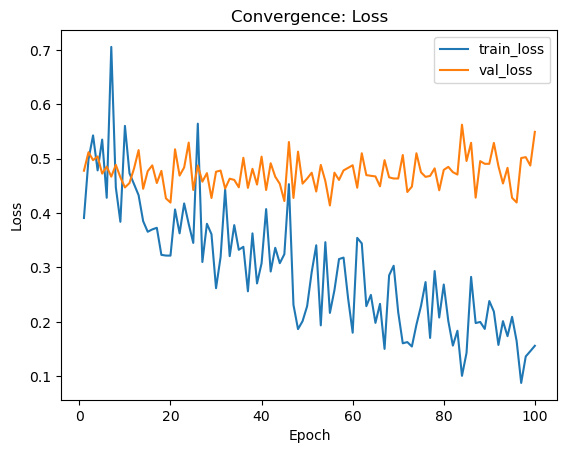

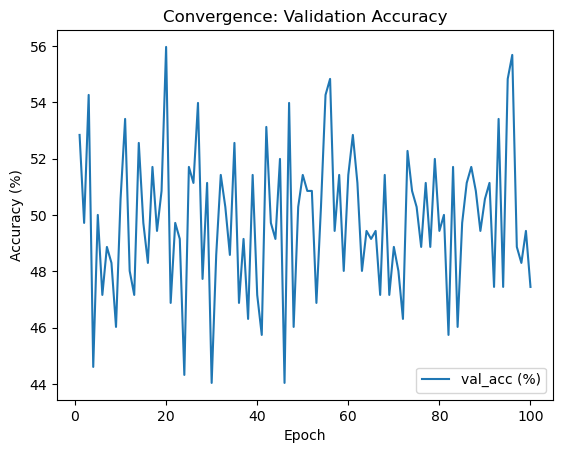


Fold 9


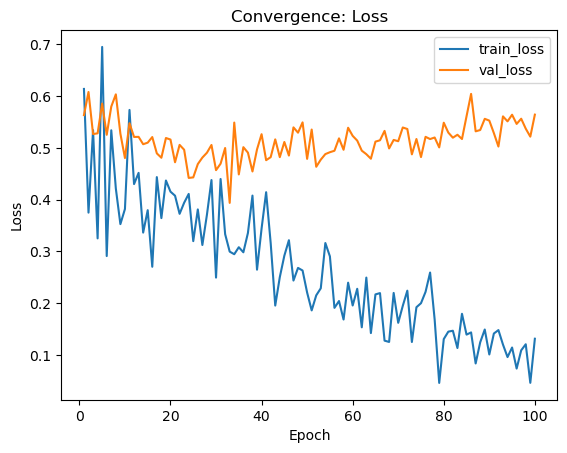

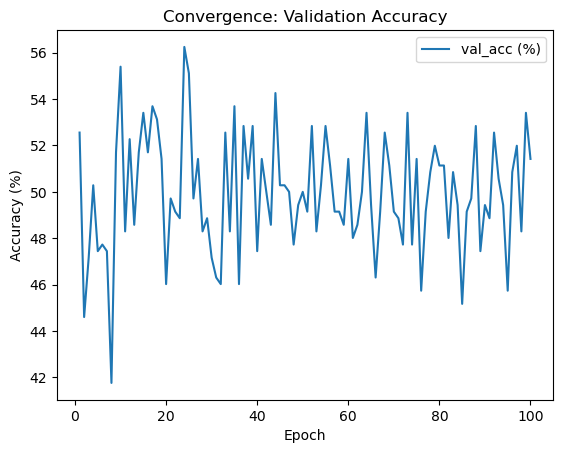


Fold 10


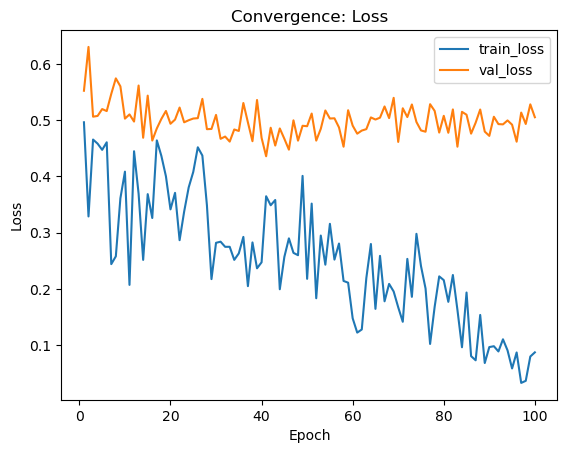

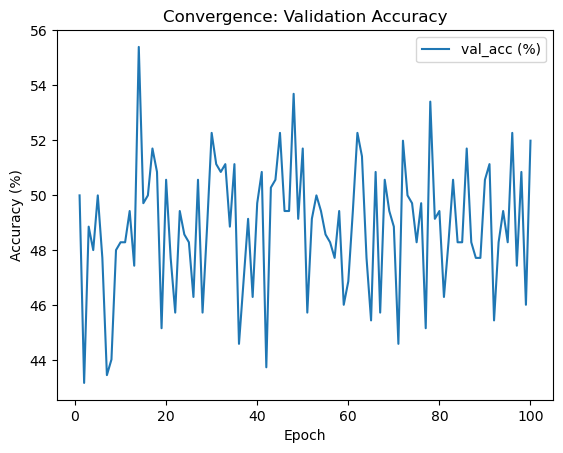

In [11]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}")

    # Split the data into training and test sets for this fold
    # Flip train and test
    X_test_np = X[train_idx]
    X_train_np  = X[test_idx]
    y_test_np = y[train_idx]
    y_train_np  = y[test_idx]
    
    # Standardize (fit on train only)
    scaler = StandardScaler()                       # computes X_scaled = (X - mu) / sigma
    X_train_np = scaler.fit_transform(X_train_np)   # applied only on the training set
    X_test_np  = scaler.transform(X_test_np)   # is applied on the test set using training statistics
    # This avoids data leakage
    # Now all features have mean 0 and variance 1 (based on training data only)
    # Neural networks train much better with standardized inputs
    
    # Convert NumPy arrays into PyTorch tensors
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.long)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.long)
    
    # Contrastive datasets/loaders
    # Each item returned by the dataset is a pair of samples (xa, xb) and their labels (ya, yb)
    # generate positive pairs (same class) and negative pairs (different class) in a controlled ratio
    train_dataset = PairDatasetBalanced(X_train, y_train)
    test_dataset = PairDatasetBalanced(X_test, y_test)
    # groups samples into batches of size bsize, shuffles the training dataset, feeds batches to the model efficiently
    pair_train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)
    pair_test_loader = DataLoader(test_dataset, batch_size=bsize)
    
    # Original loaders (for embeddings)
    # Return single samples (x, y) (no pairing, no contrastive sampling, no positive/negative logic)
    # To evaluate accuracy, F1, ROC-AUC, etc.
    train_original = TensorDataset(X_train, y_train)
    test_original = TensorDataset(X_test, y_test)
    original_train_loader = DataLoader(train_original, batch_size=bsize)
    original_test_loader = DataLoader(test_original, batch_size=bsize)

    # Free memory
    gc.collect()
    if device == "mps":
        torch.mps.empty_cache()
    if device == "cuda":
        torch.cuda.empty_cache()

    # learns a representation where “similar patients” are close and “different patients” are far
    model = DeepKernel(d_init, d_out).to(device)

    # Creates an optimizer that will update the model parameters
    # AdamW is a variant of Adam that decouples weight decay from gradient updates
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # learning rate scheduler that will reduce the learning rate during training
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step_size,
        gamma=scheduler_gamma
    )

    # Train the embedding model using pairwise hinge loss
    loss_fn = hinge_loss
    
    history = fit(
        pair_train_loader, pair_test_loader,
        model, loss_fn, optimizer, device,
        epochs=epochs, margin=margin, threshold=0.2,
        scheduler=scheduler,
        verbose=False
    )

    # Plot training curves
    plot_history(history)

    # Transform the original dataset into embeddings
    X_t, y_t = transform_dataset_contrastive(model, original_train_loader, device)
    X_ts, y_ts = transform_dataset_contrastive(model, original_test_loader, device)

    # Use those embeddings for classification
    # random forest because embeddings are low‑dimensional (16 features), 
        # they are already structured (positives close, negatives far),
        # handles small datasets well, robust to noise and give probability outputs
    clf = RandomForestClassifier(
        n_estimators=101,
        max_depth=None,
        min_samples_split=2,
        random_state=random_state,
        class_weight="balanced"  # important for imbalanced VTE, ensures minority class is not ignored.
    )
    
    clf.fit(X_t, y_t)
    
    # This is supervised learning, but on top of the learned embedding space:
    # The contrastive model learns the geometry.
    # The classifier learns the decision boundary.

    yhat = clf.predict(X_ts)
    yhat_proba = clf.predict_proba(X_ts)

    all_preds.append(yhat)
    all_y.append(y_ts)
    all_probs.append(yhat_proba)

### Results and predictions

In [12]:
all_preds = np.concatenate(all_preds)
all_y = np.concatenate(all_y)
all_probs = np.concatenate(all_probs)

## ROC, Precision-Recall curves and accuracy

In [13]:
roc_auc = roc_auc_score(all_y, all_probs[:, 1])
pr_auc = average_precision_score(all_y, all_probs[:, 1])
acc = accuracy_score(all_y, all_preds)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.5084972345980555
PR-AUC: 0.2622172038356971
Accuracy: 0.6678033532253481


In [14]:
print(classification_report(all_y, all_preds))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79      2601
           1       0.26      0.14      0.19       918

    accuracy                           0.67      3519
   macro avg       0.50      0.50      0.49      3519
weighted avg       0.61      0.67      0.63      3519



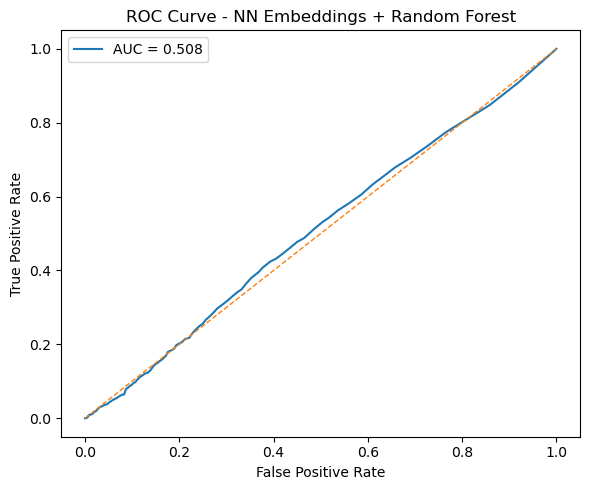

In [15]:
# --- ROC CURVE ---
fpr, tpr, _ = roc_curve(all_y, all_probs[:, 1])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NN Embeddings + Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

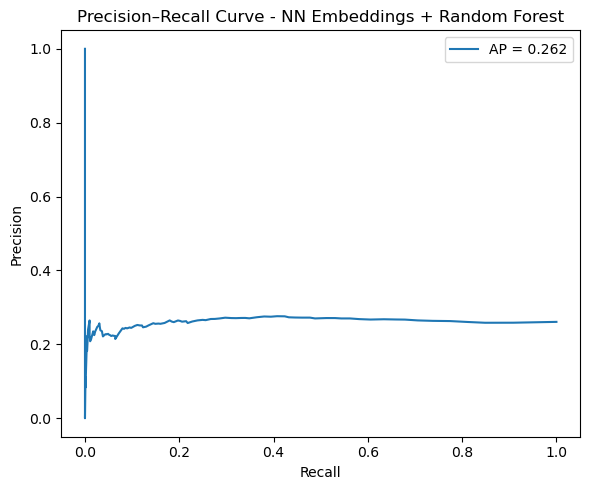

In [16]:
# --- PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(all_y, all_probs[:, 1])

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - NN Embeddings + Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# Save results to the $\texttt{.csv}$

In [17]:
df_results.loc[len(df_results)] = [
    model_name,
    random_state,
    test_size,
    epochs,
    margin,
    bsize,
    learning_rate,
    weight_decay,
    scheduler_step_size,
    scheduler_gamma,
    roc_auc,
    pr_auc,
    acc
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,ROC-AUC,PR-AUC,Accuracy
13,Contrastive,5,0.75,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.520631,0.274063,0.685422
14,Contrastive,42,0.75,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.514770,0.286427,0.674339
15,Contrastive,0,0.90,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.513333,0.277972,0.671213
16,Contrastive,5,0.90,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.517220,0.267181,0.667235
17,Contrastive,42,0.90,100,0.3,32,0.0005,1.000000e-08,300,0.01,0.508497,0.262217,0.667803


# Summary table

In [18]:
summary = (
    df_results
    .groupby(["test_size", "margin"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary

,test_size,margin,ROC-AUC,PR-AUC,Accuracy
0,0.20,0.3,0.536276,0.303598,0.687127
1,0.33,0.3,0.541302,0.312035,0.691390
2,0.50,0.3,0.540624,0.292707,0.670077
3,0.66,0.3,0.508552,0.278851,0.672634
4,0.75,0.3,0.526297,0.285104,0.682864
5,0.90,0.3,0.513017,0.269123,0.668751
